In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

In [35]:
# PATHS
PROJECT_PATH = Path("../").resolve()
DATA_PATH = PROJECT_PATH / "data"
DATA_TRAINING_SET_PATH = DATA_PATH / "UNSW_NB15_training-set.csv"
OUTPUT_PATH = PROJECT_PATH / "output"
DATA_REDUCED_5_PATH = OUTPUT_PATH / "X_reduced_5.npy"

In [36]:
df = pd.read_csv(DATA_TRAINING_SET_PATH)
true_labels = df["label"]

X = np.load(DATA_REDUCED_5_PATH)
print("Shape des données :", X.shape)

Shape des données : (82332, 6)


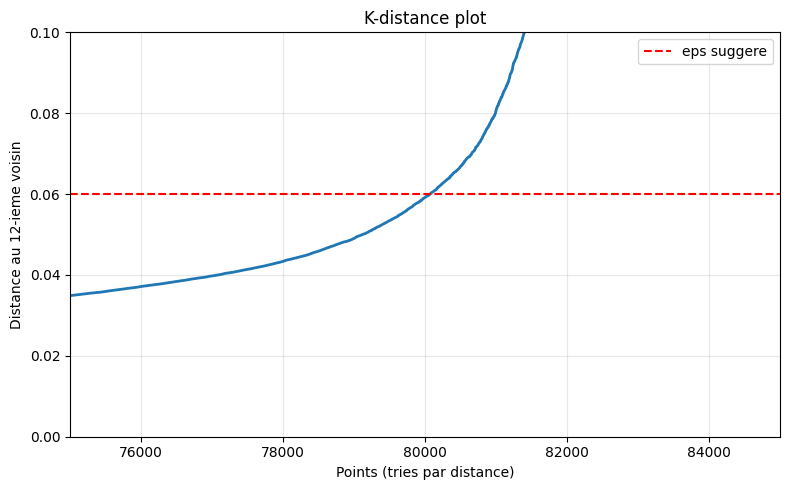

In [37]:
k = 2 * X.shape[1]
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, indices = nn.kneighbors(X)

k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2)
plt.xlabel("Points (tries par distance)")
plt.ylabel(f"Distance au {k}-ieme voisin")
plt.title("K-distance plot")
plt.grid(True, alpha=0.3)
plt.axhline(y=0.06, color="r", linestyle="--", label="eps suggere")
plt.xlim(75000, 85000)
plt.ylim(0, 0.1)

plt.legend()
plt.tight_layout()
plt.show()

Epsilon estimé : $\epsilon = 0.06$

In [42]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=7,
    n_jobs=-1,
)

labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Nombre de clusters : {n_clusters}")
print(f"Nombre de points de bruit : {n_noise}")
print(f"Taux de bruit : {n_noise / len(labels):.4f}")

ari = adjusted_rand_score(true_labels, labels)
nmi = normalized_mutual_info_score(true_labels, labels)

print("\n--- Métriques externes ---")
print(f"Adjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalized Mutual Info (NMI) : {nmi:.4f}")

Nombre de clusters : 82
Nombre de points de bruit : 173
Taux de bruit : 0.0021

--- Métriques externes ---
Adjusted Rand Index (ARI) : 0.1775
Normalized Mutual Info (NMI) : 0.3825


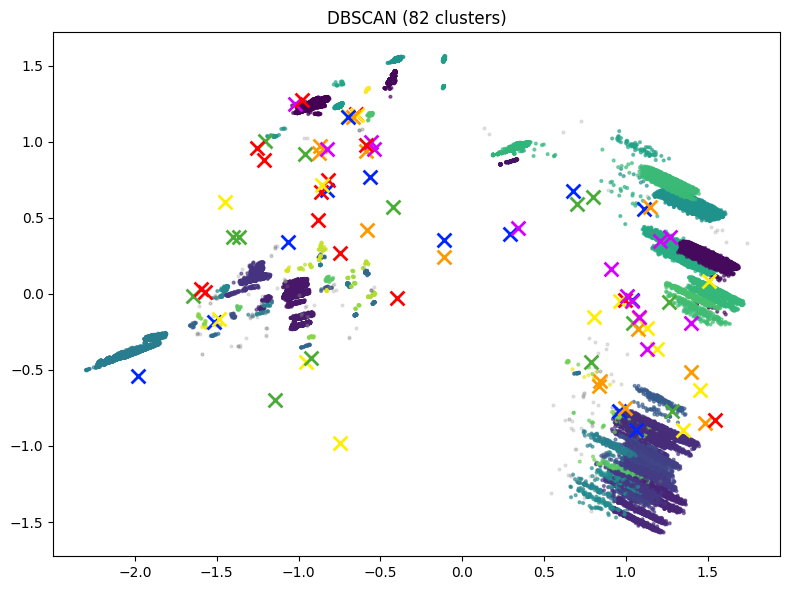

In [43]:
plt.figure(figsize=(8, 6))

mask = labels != -1
plt.scatter(
    x=X[mask, 0],
    y=X[mask, 1],
    c=labels[mask],
    cmap="viridis",
    s=4,
    alpha=0.6,
)

plt.scatter(x=X[~mask, 0], y=X[~mask, 1], color="gray", s=4, alpha=0.2, label="Bruit")

df_plot = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"])
df_plot["cluster"] = labels

centroides = (
    df_plot[df_plot["cluster"] != -1]
    .groupby("cluster")[["x1", "x3"]]
    .mean()
    .reset_index()
)

colors = ["#FF0000", "#49AC36", "#FFEE00", "#FF9900", "#0026FF", "#D400FF"]

for index, row in centroides.iterrows():
    plt.scatter(
        x=row["x1"],
        y=row["x3"],
        color=colors[int(row["cluster"]) % len(colors)],
        marker="x",
        s=100,
        linewidths=2,
        label=f"Centroïde Cluster {int(row['cluster'])}",
    )

plt.title(f"DBSCAN ({n_clusters} clusters)")
# plt.legend()

plt.tight_layout()
plt.show()